# Rebuild Model With JAX

Successfully generated 1600 valid trajectories.
Rejected 1125 short trajectories during generation.


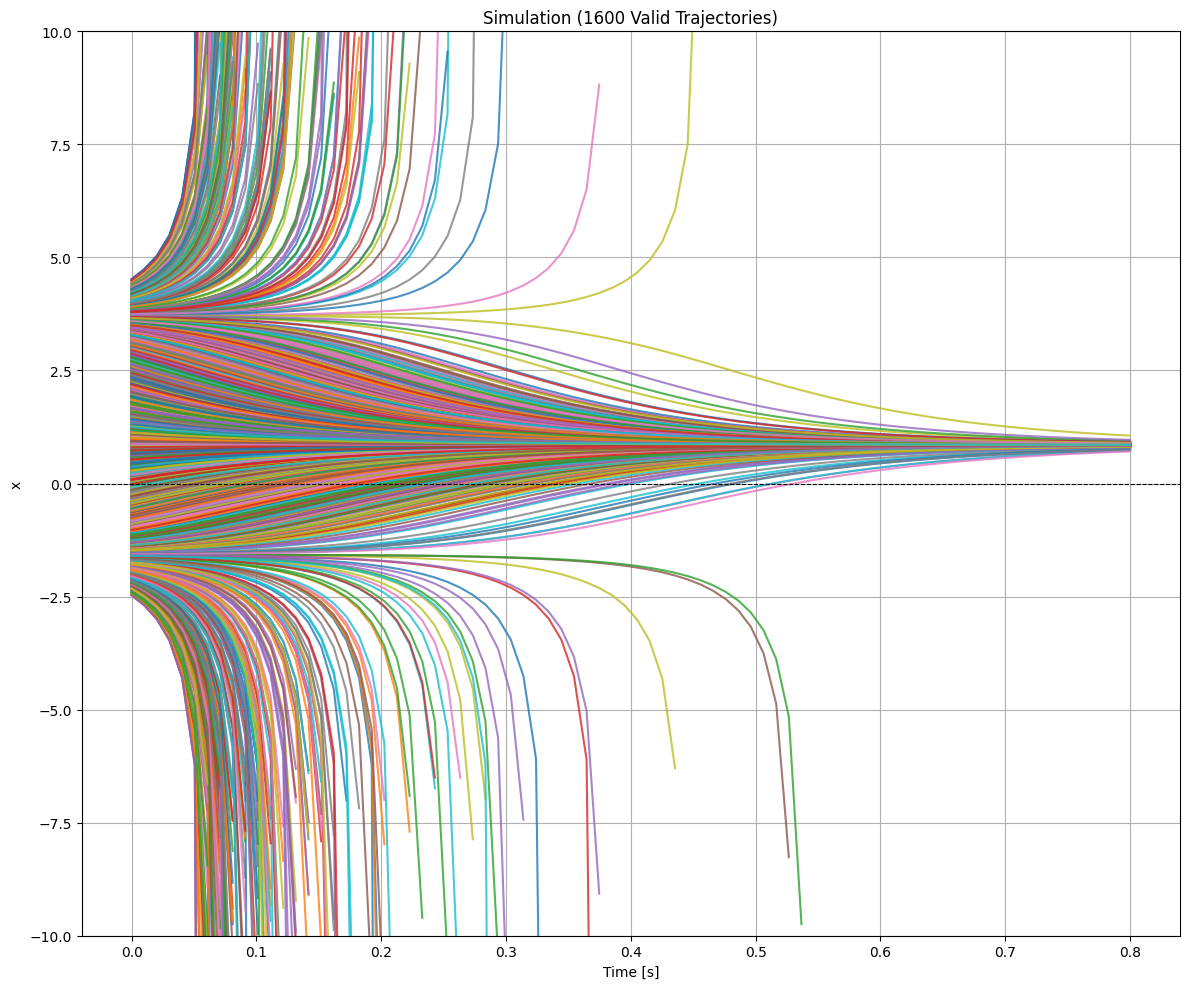

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.polynomial import Polynomial
import jax
import jax.numpy as jnp
from jax import grad, jit
import optax

# f(x) = x^3 - 4x^2  - 11x + 30
# System has 3 equilibria at [-3, 2, 5]. -3 and 5 are unstable, 2 is stable
coeffs = [5, -4, -3, 1]
poly = Polynomial(coeffs)
def f(x):
    return poly(x)
def polyDyn1d(t, y):
    return f(y)
t_span = (0, 0.8)
t_eval = np.linspace(*t_span, 80)
x0_min, x0_max = -6.0, 6.0
n_trajectories = 1600
solutions = []
all_trajectories = []
fig, (ax1) = plt.subplots(1, figsize=(12, 10))
n_trajectories_target = 1600
min_length = 7
solutions = []
all_trajectories = []
rejected_count = 0


while len(all_trajectories) < n_trajectories_target:
    x0 = np.random.uniform(x0_min, x0_max)
    solution = solve_ivp(polyDyn1d, t_span, [x0], t_eval=t_eval)
    if len(solution.y[0]) >= min_length:
        all_trajectories.append(solution.y[0])
        solutions.append(solution)
        ax1.plot(solution.t, solution.y[0], alpha=0.8)
    else:
        rejected_count += 1
        
print(f"Successfully generated {len(all_trajectories)} valid trajectories.")
print(f"Rejected {rejected_count} short trajectories during generation.")
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_title(f"Simulation ({len(all_trajectories)} Valid Trajectories)")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("x")
ax1.grid()
ax1.set_ylim(-10, 10)
plt.tight_layout()
plt.show()

In [ ]:
block_size = 10
n_embd = 2
num_heads = 1
num_layers = 1
head_size = n_embd // num_heads
dropout_rate = 0.2

# Prep Data
inputs = []
for trajectory in all_trajectories:
    for i in range(len(trajectory) - block_size):
        inputs.append(trajectory[i:i + block_size + 1])
training_inputs = inputs[:int(len(inputs)*.75)]
test_inputs = inputs[int(len(inputs)*.75):]

# Params
key = jax.random.PRNGKey(0)
key, *subkeys = jax.random.split(key, 18)
std_embed = 0.02
std_attn = 0.02
std_ffn = 0.02 / jnp.sqrt(2 * num_layers)
params = {
    'embed_weight': jax.random.normal(subkeys[0], (n_embd, 1)) * std_embed,
    'embed_bias': jnp.zeros((n_embd,)),

    'w_key_weight': jax.random.normal(subkeys[2], (head_size, n_embd)) * std_attn,
    'w_query_weight': jax.random.normal(subkeys[3], (head_size, n_embd)) * std_attn,
    'w_value_weight': jax.random.normal(subkeys[4], (head_size, n_embd)) * std_attn,

    'w_attn_output_weight': jax.random.normal(subkeys[5], (n_embd, head_size * num_heads)) * (std_attn / jnp.sqrt(2)),
    'w_attn_output_bias': jnp.zeros((n_embd,)),

    'norm_attn_gain': jnp.ones(n_embd),
    'norm_attn_bias': jnp.zeros(n_embd),

    'w_ffn_weight': jax.random.normal(subkeys[7], (4 * n_embd, n_embd)) * std_ffn,
    'w_ffn_bias': jnp.zeros((4 * n_embd,)),
    'w_ffn_output_weight': jax.random.normal(subkeys[9], (n_embd, 4 * n_embd)) * (std_ffn / jnp.sqrt(2)),
    'w_ffn_output_bias': jnp.zeros((n_embd,)),
    
    'norm_logits_gain': jnp.ones(n_embd),
    'norm_logits_bias': jnp.zeros(n_embd),

    'w_logits_output_weight': jax.random.normal(subkeys[11], (1, n_embd)) * 0.01,
    'w_logits_output_bias': jnp.zeros((1,)),
}

optimizer = optax.adam(0.001)
opt_state = optimizer.init(params)

# Forward pass function
def forward(params, input_data, key, training=True):
    embedded_input = input_data @ params['embed_weight'].T + params['embed_bias']
    K = embedded_input @ params['w_key_weight'].T
    Q = embedded_input @ params['w_query_weight'].T
    V = embedded_input @ params['w_value_weight'].T
    
    raw_attention_scores = (Q @ K.T) * (1.0 / jnp.sqrt(head_size))
    attention_probabilities = jax.nn.softmax(raw_attention_scores, axis=-1)
    if training:
        key, subkey = jax.random.split(key)
        attention_probabilities = attention_probabilities * (jax.random.uniform(subkey, attention_probabilities.shape) > dropout_rate) / (1.0 - dropout_rate)

    attention_output = (attention_probabilities @ V) @ params['w_attn_output_weight'].T + params['w_attn_output_bias']
    if training:
        key, subkey = jax.random.split(key)
        attention_output = attention_output * (jax.random.uniform(subkey, attention_output.shape) > dropout_rate) / (1.0 - dropout_rate)

    # Add + Norm (fixed normalization)
    FFN_in_raw = attention_output + embedded_input
    FFN_in_normalized = params['norm_attn_gain'] * (FFN_in_raw - FFN_in_raw.mean(axis=-1, keepdims=True)) / (FFN_in_raw.std(axis=-1, keepdims=True) + 1e-5) + params['norm_attn_bias']
   
    # FFN
    FFN_activations = jax.nn.relu(FFN_in_normalized @ params['w_ffn_weight'].T + params['w_ffn_bias'])
    FFN_output = FFN_activations @ params['w_ffn_output_weight'].T + params['w_ffn_output_bias']
    if training:
        key, subkey = jax.random.split(key)
        FFN_output = FFN_output * (jax.random.uniform(subkey, FFN_output.shape) > dropout_rate) / (1.0 - dropout_rate)

    # Add + Norm (fixed normalization)
    logits_raw = FFN_output + FFN_in_normalized
    logits_normalized = params['norm_logits_gain'] * (logits_raw - logits_raw.mean(axis=-1, keepdims=True)) / (logits_raw.std(axis=-1, keepdims=True) + 1e-5) + params['norm_logits_bias']
    
    # Linear
    logits = logits_normalized @ params['w_logits_output_weight'].T + params['w_logits_output_bias']
    
    return logits

# Loss function
def loss_fn(params, input_data, target, key):
    logits = forward(params, input_data, key, training=True)
    prediction = logits[-1, 0]
    loss = (prediction - target) ** 2
    return loss

# JIT compiled update step
@jit
def update_step(params, opt_state, input_data, target, key):
    loss, grads = jax.value_and_grad(loss_fn)(params, input_data, target, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# Training
n_epochs = 3
for epoch in range(n_epochs):
    epoch_loss = 0
    for input in training_inputs:
        input_sequence = jnp.array(input, dtype=jnp.float32)
        input_data = input_sequence[:block_size]
        input_data = input_data.reshape(-1, 1)
        target = input_sequence[-1]
        
        key, subkey = jax.random.split(key)
        params, opt_state, loss = update_step(params, opt_state, input_data, target, subkey)
        epoch_loss += loss
    
    print(f"Epoch {epoch}, Loss: {epoch_loss / len(training_inputs):.6f}")

total_params = 0
for name, p in params.items():
    n = p.size
    total_params += n
    print(f"Param {name}: {n} parameters, shape: {p.shape}")
print(f"\nTotal parameters: {total_params}")

Epoch 0, Loss: 0.984985
Epoch 1, Loss: 0.966695
Epoch 2, Loss: 1.113395
Param embed_bias: 2 parameters, shape: (2,)
Param embed_weight: 2 parameters, shape: (2, 1)
Param norm_attn_bias: 2 parameters, shape: (2,)
Param norm_attn_gain: 2 parameters, shape: (2,)
Param norm_logits_bias: 2 parameters, shape: (2,)
Param norm_logits_gain: 2 parameters, shape: (2,)
Param w_attn_output_bias: 2 parameters, shape: (2,)
Param w_attn_output_weight: 4 parameters, shape: (2, 2)
Param w_ffn_bias: 8 parameters, shape: (8,)
Param w_ffn_output_bias: 2 parameters, shape: (2,)
Param w_ffn_output_weight: 16 parameters, shape: (2, 8)
Param w_ffn_weight: 16 parameters, shape: (8, 2)
Param w_key_weight: 4 parameters, shape: (2, 2)
Param w_logits_output_bias: 1 parameters, shape: (1,)
Param w_logits_output_weight: 2 parameters, shape: (1, 2)
Param w_query_weight: 4 parameters, shape: (2, 2)
Param w_value_weight: 4 parameters, shape: (2, 2)

Total parameters: 75


# Generate Computational Graph

In [3]:
# After defining your loss_fn and before training, add:
from jax import make_jaxpr
import graphviz

# Create sample data for tracing
sample_input = jnp.ones((block_size, 1))
sample_target = jnp.array(1.0, dtype=jnp.float32)
sample_key = jax.random.PRNGKey(42)

# Generate and save graph
jaxpr = make_jaxpr(lambda p, x, k: forward(p, x, k, training=False))(params, sample_input, sample_key)

def visualize_jaxpr(jaxpr, filename='computational_graph'):
    dot = graphviz.Digraph(comment='Computation Graph', graph_attr={'rankdir': 'TB'})
    dot.attr('node', shape='box', style='rounded,filled', fillcolor='lightblue')
    
    var_to_node = {}
    
    # Add inputs
    # Add inputs with better labels
    param_names = list(params.keys())
    for i, var in enumerate(jaxpr.jaxpr.invars):
        node_id = f'input_{i}'
        if i < len(param_names):
            label = f'param: {param_names[i]}'
        elif i == len(param_names):
            label = 'input_data'
            dot.node(node_id, label, fillcolor='lightgreen')
            var_to_node[str(var)] = node_id
        else:
            label = 'random_key'
            #dot.node(node_id, label, fillcolor='lightgreen')
    
    # Add operations
    for idx, eqn in enumerate(jaxpr.jaxpr.eqns):
        node_id = f'op_{idx}'
        op_name = str(eqn.primitive)
        color = 'lightyellow' if 'dot' in op_name else 'lightcoral' if 'add' in op_name else 'lightpink' if 'softmax' in op_name or 'relu' in op_name else 'lightgray'
        dot.node(node_id, op_name, fillcolor=color)
        
        for invar in eqn.invars:
            if str(invar) in var_to_node:
                dot.edge(var_to_node[str(invar)], node_id)
        
        for outvar in eqn.outvars:
            var_to_node[str(outvar)] = node_id
    
    # Add output
    for i, var in enumerate(jaxpr.jaxpr.outvars):
        node_id = f'output_{i}'
        dot.node(node_id, 'Output', fillcolor='orange')
        if str(var) in var_to_node:
            dot.edge(var_to_node[str(var)], node_id)
    
    dot.render(filename, format='png', cleanup=True)
    print(f"Graph saved as {filename}.png")

visualize_jaxpr(jaxpr, 'computational_graph')

Graph saved as computational_graph.png


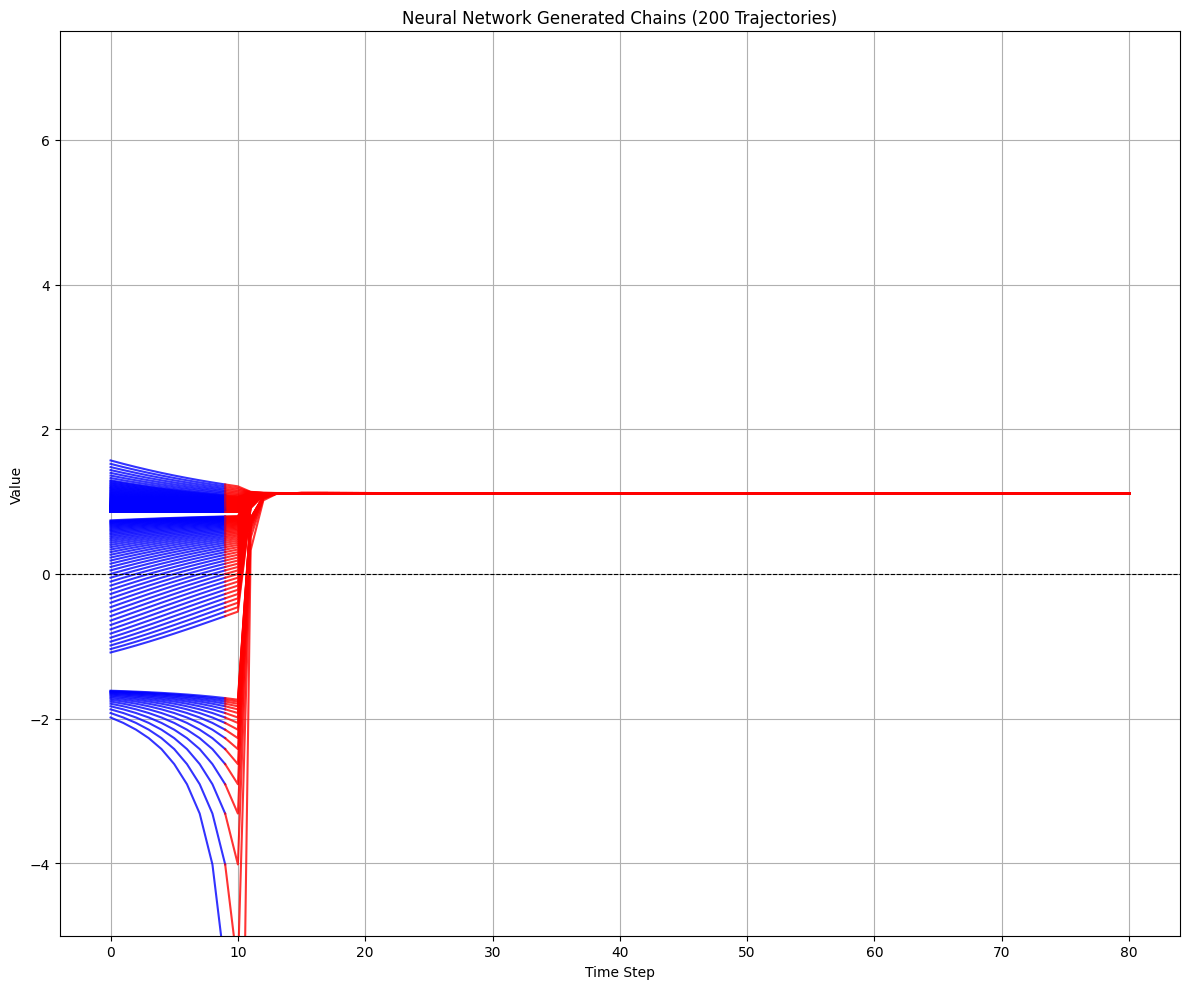

In [6]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np

chains = []
j = 0
for idx, test_input in enumerate(test_inputs[:200]):
    if test_input[0] > -2.5 and test_input[0] < 4.5:
        chain = test_input.tolist()
        chains.append(chain)
        cancel = False
        i = 10
        prediction = 0
        while i < 80 and cancel == False:
            test_input_sequence = jnp.array(test_input, dtype=jnp.float32)
            test_input_data = test_input_sequence[:block_size]
            test_input_data = test_input_data.reshape(-1, 1)
            test_target = test_input_sequence[-1]
            
            test_embedded_input = test_input_data @ params['embed_weight'].T + params['embed_bias']
            K = test_embedded_input @ params['w_key_weight'].T
            Q = test_embedded_input @ params['w_query_weight'].T
            V = test_embedded_input @ params['w_value_weight'].T
            
            raw_attention_scores = (Q @ K.T) * (1.0 / jnp.sqrt(head_size))
            attention_probabilities = jax.nn.softmax(raw_attention_scores, axis=-1)
            attention_output = (attention_probabilities @ V) @ params['w_attn_output_weight'].T + params['w_attn_output_bias']
            
            FFN_in_raw = attention_output + test_embedded_input
            FFN_in_normalized = params['norm_attn_gain'] * (FFN_in_raw - FFN_in_raw.mean(axis=-1, keepdims=True)) + params['norm_attn_bias']
            
            FFN_activations = jax.nn.relu(FFN_in_normalized @ params['w_ffn_weight'].T + params['w_ffn_bias'])
            FFN_output = FFN_activations @ params['w_ffn_output_weight'].T + params['w_ffn_output_bias']
            
            logits_raw = FFN_output + FFN_in_normalized
            logits_normalized = params['norm_logits_gain'] * (logits_raw - logits_raw.mean(axis=-1, keepdims=True)) + params['norm_logits_bias']
            
            logits = logits_normalized @ params['w_logits_output_weight'].T + params['w_logits_output_bias']
            prediction = float(logits[-1, 0])
            chain = chain[1:]
            chain.append(prediction)
            chains[j].append(prediction)
            test_input = np.array(chain[-block_size:], dtype=np.float32)
            i += 1
            if prediction < -5 or prediction > 7.5:
                cancel = True
        j += 1

fig, ax1 = plt.subplots(1, figsize=(12, 10))
for chain in chains:
    t = np.arange(len(chain))
    ax1.plot(t[:block_size], chain[:block_size], color='blue', alpha=0.8)
    ax1.plot(t[block_size-1:], chain[block_size-1:], color='red', alpha=0.8)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_title(f"Neural Network Generated Chains ({len(chains)} Trajectories)")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Value")
ax1.grid()
ax1.set_ylim(-5, 7.5)
plt.tight_layout()
plt.show()

# Linearize at a Single Point WRT Input

In [ ]:
params_0 = params
def network_output(params, input_data, key):
    logits = forward(params, input_data, key, training=False)
    return logits[-1, 0]

# Compute input Jacobian (∂output/∂input) (different from parameter Jacobian!!)
def network_wrt_input(input_data):
    return network_output(params_0, input_data, sample_key)

J_input = jax.jacobian(network_wrt_input)(sample_input) # how does output change with respect to each input element
J_input_flat = J_input.flatten() # ex. usage: [[0.5], [0.3], [0.8]] → [0.5, 0.3, 0.8]

1.5135748
1.5135791


# Show Robustness WRT Input

In [23]:
delta = 100.0
baseline_output = network_output(params_0, sample_input, sample_key)
# Worst-case change when each input perturbs to maximize output change
worst_case_change = jnp.sum(jnp.abs(J_input_flat)) * delta # Δoutput ≈ Σ(J_input[i] × Δinput[i])
upper_bound = baseline_output + worst_case_change
lower_bound = baseline_output - worst_case_change
safe_range = [-10, 10] 
print(lower_bound)
print(upper_bound)

1.5135748
1.5135791


In [ ]:
def network_output(params, input_data, key):
    logits = forward(params, input_data, key, training=False)
    return logits[-1, 0]

params_0 = params
input_sequence = test_inputs[0]
input_data = input_sequence[:block_size]
sample_input= input_data.reshape(-1, 1)
sample_key = jax.random.PRNGKey(42)

# Compute Jacobian with respect to params
jacobian_fn = jax.jacobian(network_output, argnums=0) # creates a function that computes the Jacobian
J_0 = jacobian_fn(params_0, sample_input, sample_key) # for each parameter (ie. embed_weight) J_0 will have ∂output/∂parameter[i,j] for all elements of the parameter

# Create linearized forward function
def linearized_forward(params, input_data, key):
    delta_params = jax.tree.map(lambda p, p0: p - p0, params, params_0) # computes how far current parameters are from linearization point:
    # we have dictionary of parameters, flatten to be just an array of numbers (so we can dot product)
    delta_flat, _ = jax.flatten_util.ravel_pytree(delta_params) 
    J_flat, _ = jax.flatten_util.ravel_pytree(J_0)
    # linear approximation: f(params) ≈ base_output (x-intercept) + (gradients for all elements) · (parameter changes for all elements)
            # Ex. new_output ≈ base_output + ("If I increase parameter 0 by 1.0, output increases by 0.5...") · ("Parameter 0 increased by 0.1...")
    output = f_0 + jnp.dot(J_flat, delta_flat) 
    return output

f_0 = network_output(params_0, sample_input, sample_key)

# Show Robustness of Parameters

In [ ]:
epsilon = 0.1
params_perturbed = {}
seed = 0
# Add scaled noise to all parameters
for name, param in params_0.items():
    key = jax.random.PRNGKey(seed)
    seed += 1
    params_perturbed[name] = param + epsilon *  jax.random.normal(key, param.shape)

output_original_perturbed = network_output(params_perturbed, sample_input, sample_key)
output_linearized_perturbed = linearized_forward(params_perturbed, sample_input, sample_key)
print(f"\nWith small perturbation (ε={epsilon}):")
print(f"Original output: {output_original_perturbed}")
print(f"Linearized output: {output_linearized_perturbed}")
print(f"Difference: {jnp.abs(output_original_perturbed - output_linearized_perturbed)}")

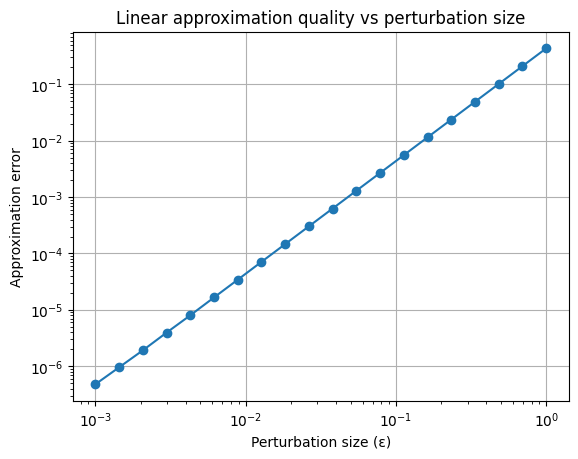

In [9]:
epsilons = jnp.logspace(-3, 0, 20)
errors = []
for eps in epsilons:
    params_test = jax.tree.map(lambda p: p + eps * jax.random.normal(jax.random.PRNGKey(42), p.shape), params_0)
    out_orig = network_output(params_test, sample_input, sample_key)
    out_linear = linearized_forward(params_test, sample_input, sample_key)
    error = jnp.abs(out_orig - out_linear)
    errors.append(error)

import matplotlib.pyplot as plt
plt.loglog(epsilons, errors, 'o-')
plt.xlabel('Perturbation size (ε)')
plt.ylabel('Approximation error')
plt.title('Linear approximation quality vs perturbation size')
plt.grid(True)
plt.show()

In [ ]:
# Each parameter has a lower and upper bound
params_lower = jax.tree_map(lambda p: p - 0.1, params_0)  # e.g., params - 0.1
params_upper = jax.tree_map(lambda p: p + 0.1, params_0)  # e.g., params + 0.1

AttributeError: jax.tree_map was removed in JAX v0.6.0: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).